In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print(f"GPU đang hoạt động: {physical_devices}")
else:
    print("Cảnh báo: Không tìm thấy GPU. Quá trình huấn luyện sẽ dùng CPU.")

GPU đang hoạt động: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
class CNNExperiment:
    def __init__(self, num_classes=10, subset_size=500, img_size=(32, 32, 3)):
        self.num_classes = num_classes
        self.subset_size = subset_size
        self.samples_per_class = subset_size // num_classes
        self.img_size = img_size

        self.X_train, self.X_test = None, None
        self.y_train, self.y_test = None, None

        self.model_flatten = None
        self.model_gap = None
        self.history_flatten = None
        self.history_gap = None

        self.time_flatten = 0
        self.time_gap = 0

    def prepare_data(self):
        print("Đang chuẩn bị dữ liệu...")
        (X_full, y_full), (_, _) = tf.keras.datasets.cifar10.load_data()

        X_subset, y_subset = [], []

        for i in range(self.num_classes):
            idx = np.where(y_full == i)[0][:self.samples_per_class]
            X_subset.append(X_full[idx])
            y_subset.append(y_full[idx])

        X_subset = np.concatenate(X_subset, axis=0)
        y_subset = np.concatenate(y_subset, axis=0)

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_subset, y_subset,
            test_size=0.3,
            stratify=y_subset,
            random_state=42
        )

        self.X_train = X_tr.astype('float32') / 255.0
        self.X_test = X_te.astype('float32') / 255.0
        self.y_train = tf.keras.utils.to_categorical(y_tr, self.num_classes)
        self.y_test = tf.keras.utils.to_categorical(y_te, self.num_classes)
        print(f"Tập train: {self.X_train.shape}, Tập test: {self.X_test.shape}")

    def _build_backbone(self):
        # KHẮC PHỤC: Khởi tạo Augmentation độc lập cho từng model
        data_augmentation = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.1),
            tf.keras.layers.RandomZoom(0.1)
        ])

        inputs = tf.keras.Input(shape=self.img_size)
        x = data_augmentation(inputs)

        x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling2D((2, 2))(x)

        x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling2D((2, 2))(x)

        x = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling2D((2, 2))(x)

        return inputs, x

    def build_models(self):
        # MÔ HÌNH A: FLATTEN
        inputs_A, backbone_A = self._build_backbone()
        x = tf.keras.layers.Flatten()(backbone_A)
        x = tf.keras.layers.Dense(128, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.5)(x)
        outputs_A = tf.keras.layers.Dense(self.num_classes, activation='softmax')(x)
        self.model_flatten = tf.keras.Model(inputs_A, outputs_A, name="CNN_Flatten")

        # MÔ HÌNH B: GAP
        inputs_B, backbone_B = self._build_backbone()
        x = tf.keras.layers.GlobalAveragePooling2D()(backbone_B)
        outputs_B = tf.keras.layers.Dense(self.num_classes, activation='softmax')(x)
        self.model_gap = tf.keras.Model(inputs_B, outputs_B, name="CNN_GAP")

    def train_and_evaluate(self, epochs=60, batch_size=32):
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5
        )
        my_callbacks = [early_stopping, reduce_lr]

        # Khởi tạo và Compile Model Flatten
        optimizer_flatten = tf.keras.optimizers.Adam(learning_rate=0.001)
        self.model_flatten.compile(optimizer=optimizer_flatten, loss='categorical_crossentropy', metrics=['accuracy'])

        print("\nBẮT ĐẦU HUẤN LUYỆN: MÔ HÌNH FLATTEN")
        start_time = time.time()
        self.history_flatten = self.model_flatten.fit(
            self.X_train, self.y_train,
            validation_data=(self.X_test, self.y_test),
            batch_size=batch_size,
            epochs=epochs,
            callbacks=my_callbacks,
            verbose=1
        )
        self.time_flatten = time.time() - start_time

        # Khởi tạo và Compile Model GAP
        optimizer_gap = tf.keras.optimizers.Adam(learning_rate=0.001)
        self.model_gap.compile(optimizer=optimizer_gap, loss='categorical_crossentropy', metrics=['accuracy'])

        print("\nBẮT ĐẦU HUẤN LUYỆN: MÔ HÌNH GAP")
        start_time = time.time()
        self.history_gap = self.model_gap.fit(
            self.X_train, self.y_train,
            validation_data=(self.X_test, self.y_test),
            batch_size=batch_size,
            epochs=epochs,
            callbacks=my_callbacks,
            verbose=1
        )
        self.time_gap = time.time() - start_time

    def analyze_results(self):
        loss_f, acc_f = self.model_flatten.evaluate(self.X_test, self.y_test, verbose=0)
        loss_g, acc_g = self.model_gap.evaluate(self.X_test, self.y_test, verbose=0)

        print("\n--- BÁO CÁO KẾT QUẢ TỔNG QUAN ---")
        print(f"{'Metric':<15} | {'CNN + Flatten':<15} | {'CNN + GAP':<15}")
        print("-" * 50)
        print(f"{'Test Accuracy':<15} | {acc_f:.4f}{'':<9} | {acc_g:.4f}")
        print(f"{'Test Loss':<15} | {loss_f:.4f}{'':<9} | {loss_g:.4f}")
        print(f"{'Train Time (s)':<15} | {self.time_flatten:.2f}{'':<9} | {self.time_gap:.2f}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(self.history_flatten.history['accuracy'], label='Train Flatten', linestyle='--')
        axes[0].plot(self.history_flatten.history['val_accuracy'], label='Val Flatten', linewidth=2)
        axes[0].plot(self.history_gap.history['accuracy'], label='Train GAP', linestyle='--')
        axes[0].plot(self.history_gap.history['val_accuracy'], label='Val GAP', linewidth=2)
        axes[0].set_title('Model Accuracy')
        axes[0].set_ylabel('Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].legend()

        axes[1].plot(self.history_flatten.history['loss'], label='Train Flatten', linestyle='--')
        axes[1].plot(self.history_flatten.history['val_loss'], label='Val Flatten', linewidth=2)
        axes[1].plot(self.history_gap.history['loss'], label='Train GAP', linestyle='--')
        axes[1].plot(self.history_gap.history['val_loss'], label='Val GAP', linewidth=2)
        axes[1].set_title('Model Loss')
        axes[1].set_ylabel('Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

In [15]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)
experiment = CNNExperiment()
experiment.prepare_data()

Đang chuẩn bị dữ liệu...
Tập train: (350, 32, 32, 3), Tập test: (150, 32, 32, 3)


In [16]:
experiment.build_models()


--- SO SÁNH PARAMETERS ---
Tổng tham số Model Flatten: 357,706
Tổng tham số Model GAP: 95,434
-------------------------


In [17]:
experiment.train_and_evaluate(epochs=60, batch_size=32)


BẮT ĐẦU HUẤN LUYỆN: MÔ HÌNH FLATTEN
Epoch 1/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.1086 - loss: 3.5523 - val_accuracy: 0.1600 - val_loss: 2.2911 - learning_rate: 0.0010
Epoch 2/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2514 - loss: 2.2655 - val_accuracy: 0.1333 - val_loss: 2.3114 - learning_rate: 0.0010
Epoch 3/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2543 - loss: 2.0036 - val_accuracy: 0.1200 - val_loss: 2.5092 - learning_rate: 0.0010
Epoch 4/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2714 - loss: 1.9852 - val_accuracy: 0.1000 - val_loss: 2.8647 - learning_rate: 0.0010
Epoch 5/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3314 - loss: 1.9044 - val_accuracy: 0.1200 - val_loss: 3.2616 - learning_rate: 0.0010
Epoch 6/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3486 - loss: 1.8755 - val_accuracy: 0.1533 - val_loss: 3.5836 - learning_rate: 0.0010
Epoch 7/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accu


--- BÁO CÁO KẾT QUẢ TỔNG QUAN ---
Metric          | CNN + Flatten   | CNN + GAP      
--------------------------------------------------
Test Accuracy   | 0.1600          | 0.1400
Test Loss       | 2.2911          | 2.2948
Train Time (s)  | 6.61          | 4.99


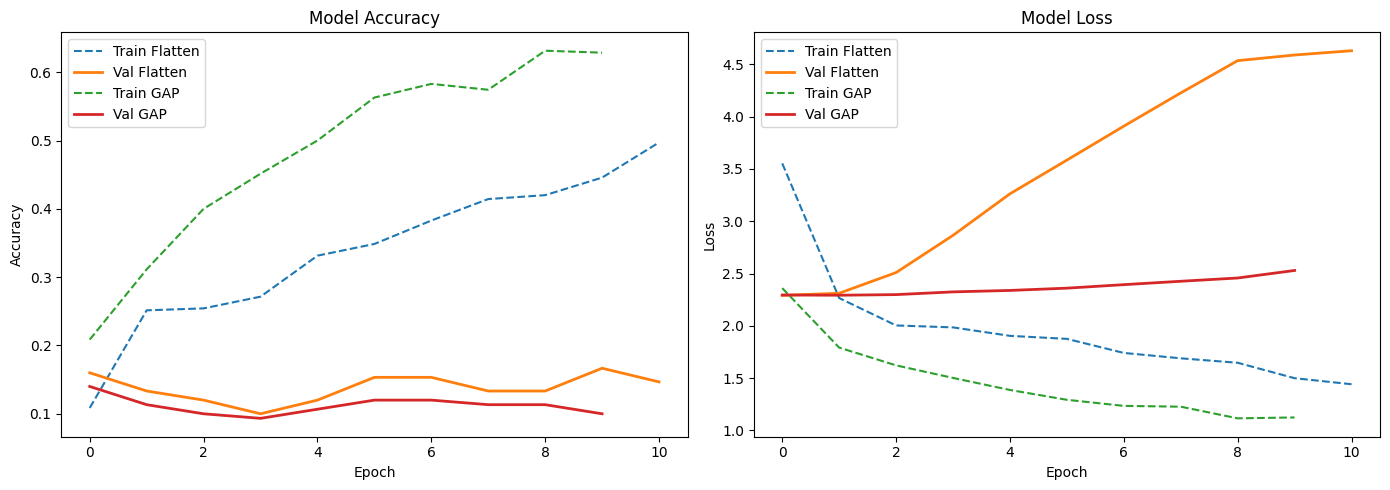


Phân tích chi tiết cho mô hình tốt nhất: CNN_Flatten
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.00      0.00      0.00        15
  automobile       0.00      0.00      0.00        15
        bird       0.14      0.60      0.23        15
         cat       0.00      0.00      0.00        15
        deer       0.00      0.00      0.00        15
         dog       0.00      0.00      0.00        15
        frog       0.00      0.00      0.00        15
       horse       0.17      0.33      0.22        15
        ship       0.24      0.53      0.33        15
       truck       0.18      0.13      0.15        15

    accuracy                           0.16       150
   macro avg       0.07      0.16      0.09       150
weighted avg       0.07      0.16      0.09       150



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


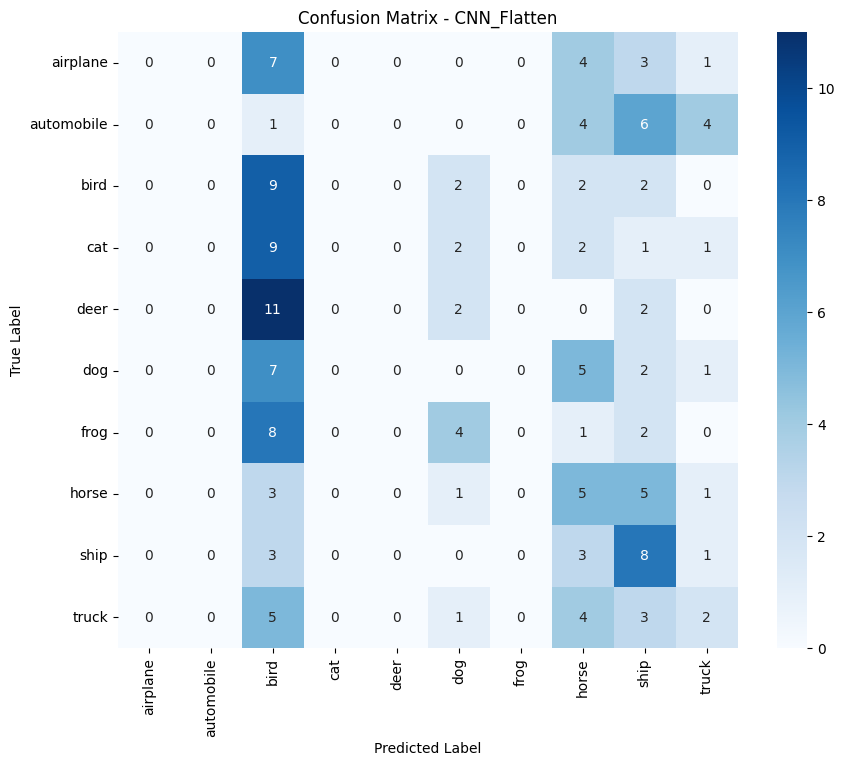

In [18]:
experiment.analyze_results()